# Diabetes Prediction — Module 3: Model Evaluation

This notebook will work on the `test_cleaned.csv` to find how do the four tuned models perform on patients they've never influenced in any way.

Let's evaluate all four saved models (Logistic Regression, KNN, Decision Tree, Random Forest), compare Accuracy against ROC-AUC, and only then pick a final model — showing both metrics' verdicts

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score, roc_auc_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, classification_report,
)
from matplotlib.colors import ListedColormap

sns.set_theme(style="whitegrid")

## Loading the test set and Module 2's saved artifacts

In [10]:
test_df = pd.read_csv('C:/Users/Priyanshu/Projects/mentorminds/diabetes_onset_prediction/data/test_cleaned.csv')

models = joblib.load("C:/Users/Priyanshu/Projects/mentorminds/diabetes_onset_prediction/Module_2_feature_engineering_modelling/models/final_models.joblib")
scaler = joblib.load("C:/Users/Priyanshu/Projects/mentorminds/diabetes_onset_prediction/Module_2_feature_engineering_modelling/models/scaler.joblib")
selected_features = joblib.load("C:/Users/Priyanshu/Projects/mentorminds/diabetes_onset_prediction/Module_2_feature_engineering_modelling/models/feature_cols.joblib")

print("Models loaded:", list(models.keys()))
print("Selected features:", selected_features)
print("Test set shape:", test_df.shape)

Models loaded: ['Logistic Regression', 'KNN', 'Decision Tree', 'Random Forest']
Selected features: ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin']
Test set shape: (154, 11)


## Applying the same preprocessing Module 2 used

In [11]:
diagnostic_features = [c for c in test_df.columns if c != 'Outcome']

x_test_scaled_full = pd.DataFrame(scaler.transform(test_df[diagnostic_features]), columns=diagnostic_features, index=test_df.index)
x_test = x_test_scaled_full[selected_features]
y_test = test_df["Outcome"]

print("Final evaluation feature set:", list(x_test.columns))
x_test.head()


Final evaluation feature set: ['Glucose', 'BMI', 'Age', 'DiabetesPedigreeFunction', 'Insulin']


,Glucose,BMI,Age,DiabetesPedigreeFunction,Insulin
0,1.245157,-0.754319,0.572372,-0.593708,-0.143345
1,-1.790266,0.470710,1.172094,-0.624761,-1.373682
2,0.010974,0.531206,-0.627070,0.058416,1.070804
3,-0.255876,-0.754319,0.058326,0.917562,-0.143345
4,-1.590128,0.001872,-0.969768,-1.256182,-0.143345


## Evaluate all four models on the test set

For each model: Accuracy, ROC-AUC, Precision, Recall, and F1. We need more than Accuracy
here because missing a diabetic patient (a false negative, captured by Recall) is a more serious failure than flagging a healthy patient for a follow-up test (a false positive).

In [12]:
results = []

for name, model in models.items():
    preds = model.predict(x_test)
    proba = model.predict_proba(x_test)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, proba),
        'Precision': precision_score(y_test, preds),
        'Recall': recall_score(y_test, preds),
        'F1': f1_score(y_test, preds)
    })

results_df = pd.DataFrame(results).set_index('Model')
results_df.round(4)

,Accuracy,ROC-AUC,Precision,Recall,F1
Model,,,,,
Logistic Regression,0.7208,0.7946,0.6279,0.5000,0.5567
KNN,0.7468,0.8214,0.6531,0.5926,0.6214
Decision Tree,0.6883,0.7641,0.6364,0.2593,0.3684
Random Forest,0.7403,0.8180,0.6591,0.5370,0.5918


In [32]:
custom_color = ["#FB542E", '#008080']

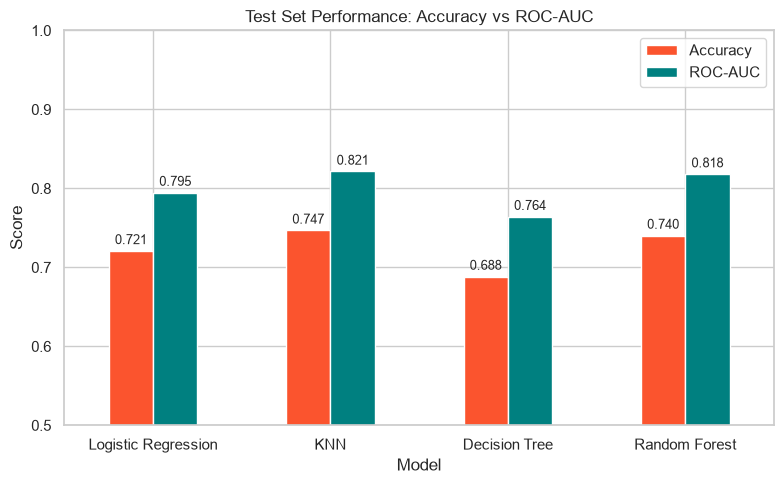

In [33]:
ax = results_df[["Accuracy", "ROC-AUC"]].plot(kind="bar", figsize=(8, 5), colormap=ListedColormap(custom_color))
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=9, xytext=(0, 3), textcoords='offset points')

plt.title("Test Set Performance: Accuracy vs ROC-AUC")
plt.ylabel("Score")
plt.ylim(0.5, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Confusion matrices

Each matrix shows:
+ correctly identified healthy patients (top-left)
+ false alarms (top-right)
+ **missed diabetic patients (bottom-left)**
+ correctly caught diabetic patients (bottom-right)

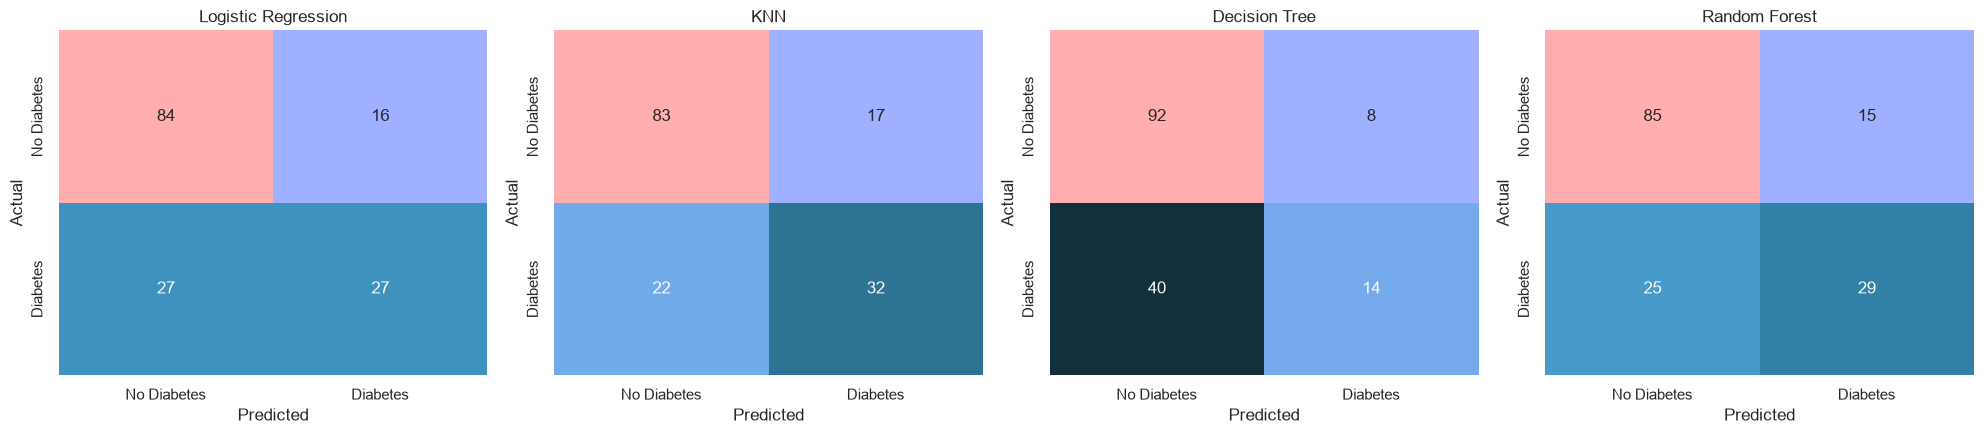

In [31]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(x_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='berlin', cbar=False, ax=ax, xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## ROC curves — all four models 

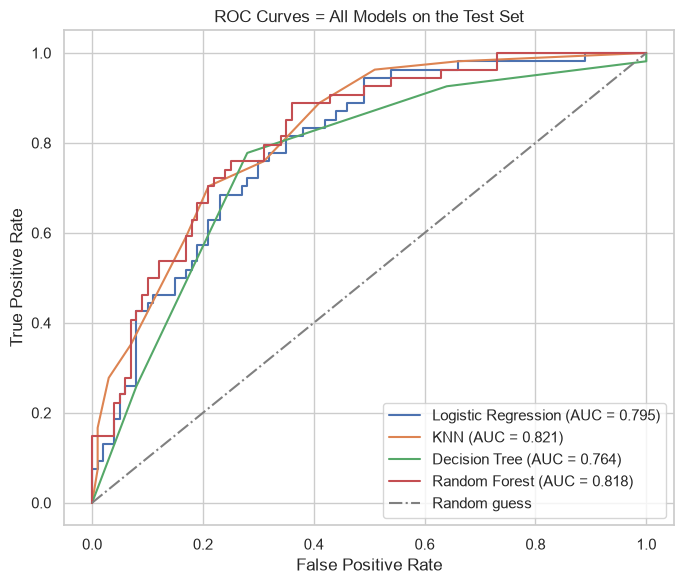

In [16]:
plt.figure(figsize=(7, 6))

for name, model in models.items():
    proba = model.predict_proba(x_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle = '-.', color='gray', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves = All Models on the Test Set')
plt.legend()
plt.tight_layout()
plt.show()

### Checking if Accuracy and ROC-AUC agree on the best model

In [17]:
best_accu = results_df['Accuracy'].idxmax()
best_roc_auc = results_df['ROC-AUC'].idxmax()

print(f'Best model by Accuracy: {best_accu} ({results_df.loc[best_accu, 'Accuracy']:.4f})')
print(f'Best model by Accuracy: {best_roc_auc} ({results_df.loc[best_roc_auc, 'ROC-AUC']:.4f})')

if best_accu == best_roc_auc:
    print(f'\nBoth metrics agree: {best_accu} is the strongest model on the test set.')
else:
    print(f'\nThe two metrics DISAGREE on the strongest model.')

Best model by Accuracy: KNN (0.7468)
Best model by Accuracy: KNN (0.8214)

Both metrics agree: KNN is the strongest model on the test set.


## Final Model Selection

In [18]:
final_model_name = best_roc_auc if best_accu != best_roc_auc else best_accu
final_model = models[final_model_name]

print(f"Final model selected: {final_model_name}")
print()
print(classification_report(y_test, final_model.predict(x_test), target_names=["No Diabetes", "Diabetes"]))


Final model selected: KNN

              precision    recall  f1-score   support

 No Diabetes       0.79      0.83      0.81       100
    Diabetes       0.65      0.59      0.62        54

    accuracy                           0.75       154
   macro avg       0.72      0.71      0.72       154
weighted avg       0.74      0.75      0.74       154



## Summary
+ Loaded the raw test set amd applied the same preprocessing as Module 2.
+ Evaluated all four tuned models on Accuracy, ROC-AUC, Precision, Recall and F1.
+ Compared confuison matrices and ROC curves across all four models.
+ Checked if Accuracy and ROC-AUC agree on a winner, and picked the final model based on reasoning.